# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [1]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [2]:
filename="../Lab.7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

In [9]:
pip install -U scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 36.3 MB/s eta 0:00:00 MB/s eta 0:00:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.8.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

X = df.drop("signal", axis=1)
y = df["signal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
pred_lr = log_model.predict(X_test)

print("Logistic Regression predictions:")
print(pred_lr)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
pred_lda = lda.predict(X_test)

print("\nLDA predictions:")
print(pred_lda)

Logistic Regression predictions:
[0. 0. 0. ... 1. 1. 0.]

LDA predictions:
[0. 0. 0. ... 1. 1. 0.]


In [4]:
model = LogisticRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

In [5]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
predictions = lda.predict(X_test)

### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [6]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [7]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [8]:
Fisher.fit(X_Train,y_Train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


We can plot the output, comparing signal and background:

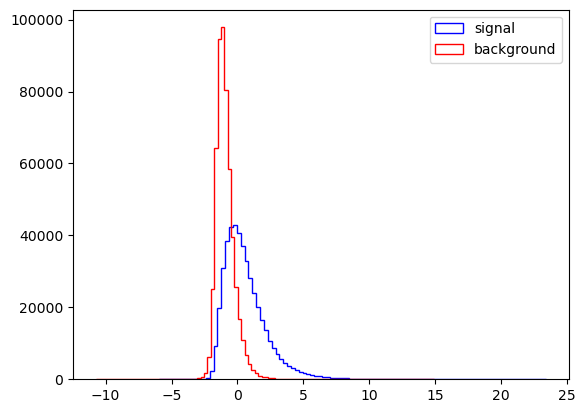

In [9]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

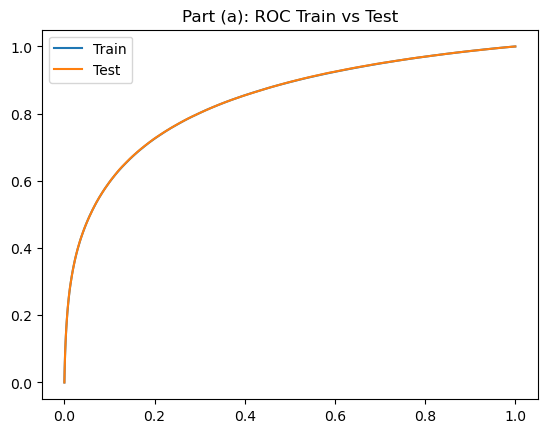

In [17]:
from sklearn.metrics import roc_curve, auc

Fisher = DA.LinearDiscriminantAnalysis()
Fisher.fit(X_Train, y_Train)

train_scores = Fisher.decision_function(X_Train)
test_scores = Fisher.decision_function(X_Test)

fpr_tr, tpr_tr, _ = roc_curve(y_Train, train_scores)
fpr_te, tpr_te, _ = roc_curve(y_Test, test_scores)

plt.figure()
plt.plot(fpr_tr, tpr_tr, label="Train")
plt.plot(fpr_te, tpr_te, label="Test")
plt.title("Part (a): ROC Train vs Test")
plt.legend()
plt.show()

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

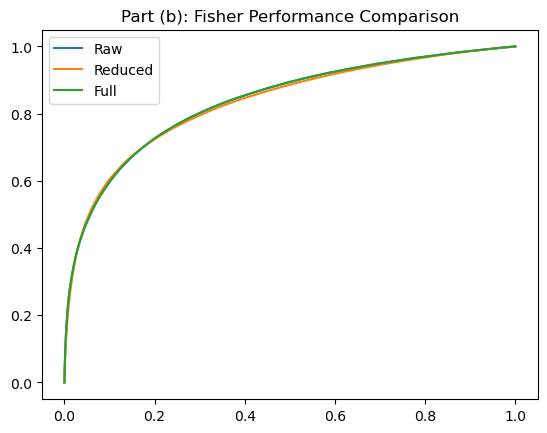

In [18]:
mid = len(VarNames[1:]) // 2

X_Train_raw = Train_Sample[VarNames[1:]]
X_Test_raw = Test_Sample[VarNames[1:]]

X_Train_red = Train_Sample[VarNames[1:][:mid]]
X_Test_red = Test_Sample[VarNames[1:][:mid]]

X_Train_full = X_Train_raw
X_Test_full = X_Test_raw

Fisher = DA.LinearDiscriminantAnalysis()

Fisher.fit(X_Train_raw, y_Train)
score_raw = Fisher.decision_function(X_Test_raw)
Fisher.fit(X_Train_red, y_Train)
score_red = Fisher.decision_function(X_Test_red)
Fisher.fit(X_Train_full, y_Train)
score_full = Fisher.decision_function(X_Test_full)

fpr_raw, tpr_raw, _ = roc_curve(y_Test, score_raw)
fpr_red, tpr_red, _ = roc_curve(y_Test, score_red)
fpr_full, tpr_full, _ = roc_curve(y_Test, score_full)

plt.figure()
plt.plot(fpr_raw, tpr_raw, label="Raw")
plt.plot(fpr_red, tpr_red, label="Reduced")
plt.plot(fpr_full, tpr_full, label="Full")
plt.title("Part (b): Fisher Performance Comparison")
plt.legend()
plt.show()

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

In [37]:
from sklearn.tree import DecisionTreeClassifier

def compare_classifiers(X_train, X_test, y_train, y_test):
    plt.figure()

    models = [
        ("LDA", DA.LinearDiscriminantAnalysis()),
        ("LogReg", LogisticRegression(max_iter=1000)),
        ("Tree", DecisionTreeClassifier())]

    for name, model in models:
        model.fit(X_train, y_train)
        if hasattr(model, "decision_function"):
            scores = model.decision_function(X_test)
        else:
            scores = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, scores)
        plt.plot(fpr, tpr, label=name)

    plt.plot([0,1],[0,1],'--',color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Classifier Comparison (ROC)")
    plt.legend()
    plt.show()

In [31]:
def compute_significance(X_train, X_test, y_train, y_test):
    models = [
        ("LDA", DA.LinearDiscriminantAnalysis()),
        ("LogReg", LogisticRegression(max_iter=1000)),
        ("Tree", DecisionTreeClassifier())]

    for name, model in models:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        NS = np.sum((y_test == 1) & (y_pred == 1))
        NB = np.sum((y_test == 0) & (y_pred == 1))

        sig = NS / np.sqrt(NS + NB) if (NS + NB) > 0 else 0
        print(name, "Significance:", sig)

In [32]:
compute_significance(X_train, X_test, y_train, y_test)

LDA Significance: 471.899051938251
LogReg Significance: 506.63894532942965
Tree Significance: 467.5972056232075


### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

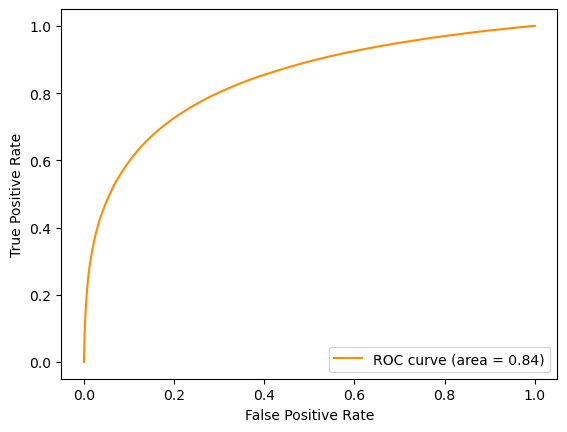

In [15]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

pred = Fisher.predict(X_Test)

precision = precision_score(y_Test, pred)
recall = recall_score(y_Test, pred)
f1 = f1_score(y_Test, pred)
accuracy = accuracy_score(y_Test, pred)

signal = Test_Sample[Test_Sample.signal == 1]
background = Test_Sample[Test_Sample.signal == 0]

S = len(signal)
B = len(background)

significance = S / np.sqrt(S + B)

print("AUC = ", roc_auc)
print("Precision = ", precision)
print("Recall = ", recall)
print("F1-score = ", f1)
print("Accuracy = ", accuracy)
print("Significance = ", significance)

AUC =  0.8364009731285001
Precision =  0.8444914333899756
Recall =  0.5769772146484431
F1-score =  0.6855618176372893
Accuracy =  0.757471
Significance =  458.233
